# CABR

In [1]:
# --------------------------------------------------------
# External packages
import matplotlib.pyplot as plt
import jax.numpy as jnp

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import CABR
from KiRATE.utilities import calculate_effective_concentration

- Equations
    > $k_f \: (T, P) = k_{0} \left(\dfrac{1}{1+P_{r}}\right)F(T, P_r) $
    >
    > - $P_r$ is the reduce pressure computed as follow: $P_r = \dfrac{k_{0}[M]}{k_{\infty}}$
    > - $[M]$ is the concentration of the mixture, possibly including enhanced third-body efficiencies.
    > - $k_0$ and $k_{\infty}$ are the low pressure and high pressure limits of the rate constant computed as a classic Arrhenius constant.
    >
    > - $F(T, P_r)$ is the blending function that depending on different formalism is computed in different ways.

## Lindemann

In [18]:
# --------------------------------------------------------
# Direct parameters initialization
lindemann = CABR(
    name="CH3+CH3(+M)=H+C2H5(+M)",
    lpl_parameters={"A": 4.989e12, "n": 0.099, "Ea": 10600.0},
    hpl_parameters={"A": 3.80e-7, "n": 4.838, "Ea": 7710.0},
    cabr_type="lindemann",
)

lindemann = CABR.from_chemkin(
    """
    CH3 + CH3(+M) = H + C2H5(+M)       4.989E+12  0.099  10600.
     HIGH /                            3.800E-07  4.838  7710. /
    """
)

## Kinetic constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the FallOff object, including the calculation of the kinetic constant across different temperature and pressure ranges.

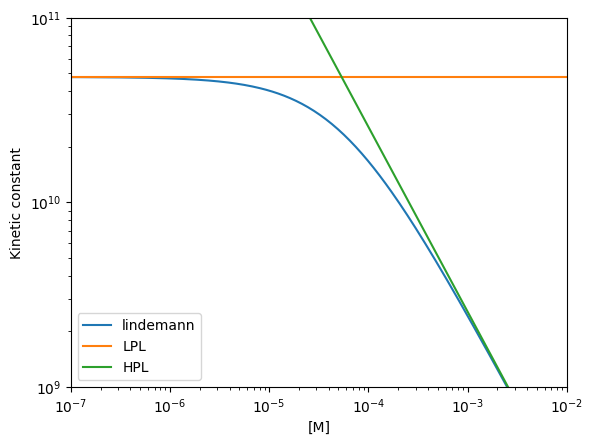

In [12]:
P_range = jnp.logspace(jnp.log10(0.001), jnp.log10(1000), 300)

hpl = lindemann.hpl.rate_constant(jnp.array([1000] * 300))
lpl = lindemann.lpl.rate_constant(jnp.array([1000] * 300))
k_lindemann = lindemann.rate_constant(1000, P_range)
M = calculate_effective_concentration(1000, P_range)

fig, ax = plt.subplots()
ax.plot(M, k_lindemann, label="lindemann")
ax.plot(M, lpl, label="LPL")
ax.plot(M, hpl / M, label="HPL")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-7, 0.01])
ax.set_ylim([1e9, 1e11])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()

## TROE

### TODO

In [4]:
# --------------------------------------------------------
# Parameters initialization

## Kinetic constant computation

In [15]:
# --------------------------------------------------------
# Direct parameters initialization
sri = CABR(
    name="CH3+CH3(+M)=H+C2H5(+M)",
    lpl_parameters={"A": 4.989e12, "n": 0.099, "Ea": 10600.0},
    hpl_parameters={"A": 3.80e-7, "n": 4.838, "Ea": 7710.0},
    cabr_type="sri",
    cabr_parameters={"a": 1.641, "b": 4334, "c": 2725, "d": 1, "e": 0},
)

sri = CABR.from_chemkin(
    """
    CH3 + CH3(+M) = H + C2H5(+M)       4.989E+12  0.099  10600.
     HIGH /                            3.800E-07  4.838  7710. /
     SRI  /                            1.641 4334 2725         /
    """
)

## SRI
- Equations
    > $F = d\left[a\times exp\left(-b/T\right) + exp\left(-T/c\right)\right]^{\chi} T^{e}$
    > 
    > $\chi = \dfrac{1}{1 + log_{10}^{2}P_{r}}$
- CHEMKIN representation
    >```
    > CH3 + CH3(+M) = H + C2H5(+M)       4.989E+12  0.099  10600.  ! Stewart
    >  HIGH /                            3.800E-07  4.838  7710. / ! Chemically activated reaction
    > SRI   / 1.641 4334 2725                                    /
    >```
- Internal representation
    >```python
    >```

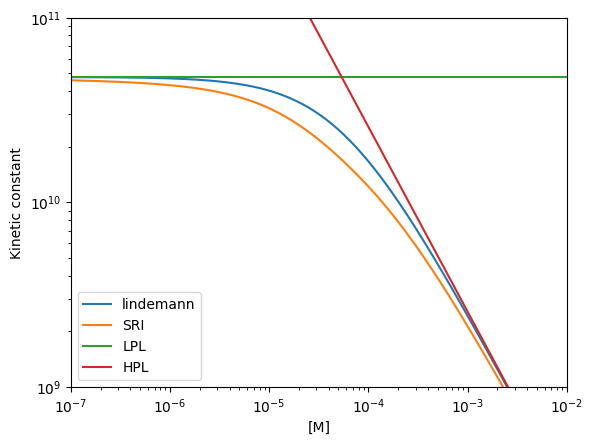

In [16]:
P_range = jnp.logspace(jnp.log10(0.001), jnp.log10(1000), 300)

hpl = sri.hpl.rate_constant(jnp.array([1000] * 300))  # Compute the value of the HPL
lpl = sri.lpl.rate_constant(jnp.array([1000] * 300))  # Compute the value of the LPL
k_sri = sri.rate_constant(1000, P_range)  # Kinetic constant here returns also M just to ease subsequent plotting stuff

fig, ax = plt.subplots()
ax.plot(M, k_lindemann, label="lindemann")
ax.plot(M, k_sri, label="SRI")
ax.plot(M, lpl, label="LPL")
ax.plot(M, hpl / M, label="HPL")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-7, 0.01])
ax.set_ylim([1e9, 1e11])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()